In [1]:
from src.data import Strategy
from src.matching import Matching
from src.evaluation import Evaluation
import numpy as np
import seaborn as sns
import pickle
from matplotlib.patches import Rectangle
from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
# amsdata = pickle.load(open('data/ams_data_rsd_notplaced.pkl', 'rb'))
# synthdata = pickle.load(open('data/synth_data_rsd_not_placed.pkl', 'rb'))
ams_scenario_labels = ["vwo", "havo/vwo", "vmbo"]
synth_scenario_labels = ["Exponential", "Linear", "Logistic"]
topns = [1, 2, 3, "Mixed-n"]
fractions = [1.0, .75, .50, .25]
RUNS = 50
evaluation = Evaluation()

In [3]:
# for label in synth_scenario_labels:
#     for run in tqdm(range(RUNS)):
#         agents = synthdata[label]['agents'][run]
#         items = synthdata[label]['items'][run]
#         not_placed_id = synthdata[label]['Not Placed']
#         strategy = Strategy(seed=2710, agents=agents, items=items, not_placed_id=not_placed_id)
#
#         for i, topn in enumerate(topns):
#             for j, fraction in enumerate(fractions):
#                 slabel = f'RM-HAL, n={topn}, f={fraction}'
#                 alabel = f'agents, n={topn}, f={fraction}'
#                 strategic_agents, strategic_agent_ids = strategy.get_strategic_agents(stype="FOH", fraction=fraction, topn=topn, cutoff=False)
#                 matching_s = Matching(agents=strategic_agents, items=items, not_placed_id=not_placed_id)
#                 allocation_ha_s = matching_s.hungarian_algorithm()
#                 if slabel not in synthdata[label]:
#                     synthdata[label][slabel] = []
#                 if alabel not in synthdata[label]:
#                     synthdata[label][alabel] = []
#                 synthdata[label][slabel].append(allocation_ha_s)
#                 synthdata[label][alabel].append((strategic_agents, strategic_agent_ids))

In [4]:
# pickle.dump(synthdata, open('synth_data_full_rsd.pkl', 'wb'))

In [5]:
FONTSIZE = 14

In [6]:
amsdata = pickle.load(open('data/ams_data_full_rsd.pkl', 'rb'))
synthdata = pickle.load(open('data/synth_data_full_rsd.pkl', 'rb'))

In [14]:
selected_data = synthdata
selected_market = synth_scenario_labels
name = 'synth'

3.0921999999999996
2.7443799999999996
2.0366600000000004


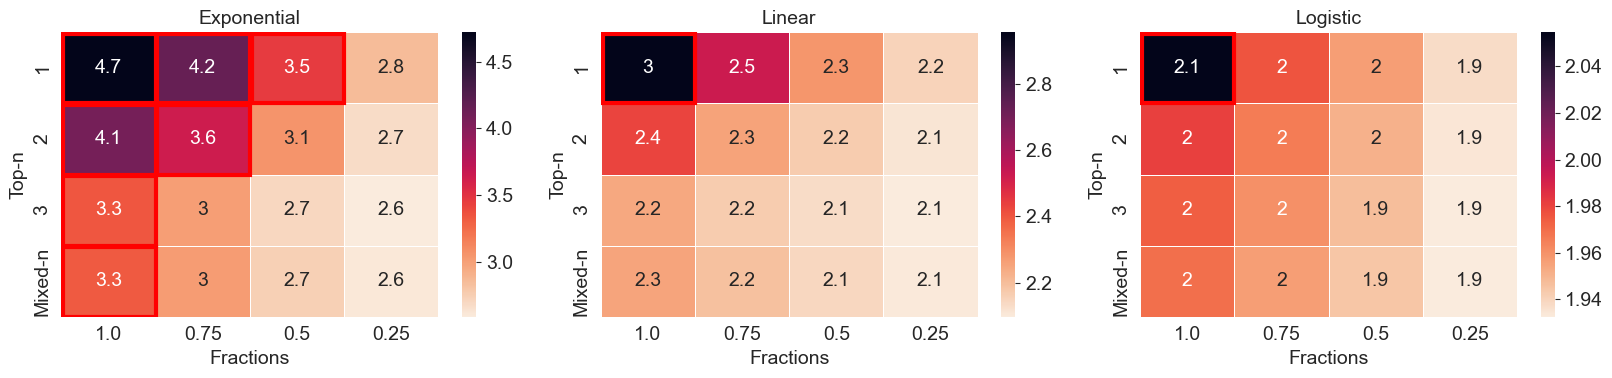

In [15]:
N_COL = 3
N_ROW = 1
fig, ax = plt.subplots(N_ROW,N_COL)
plt.rcParams.update({'font.size': FONTSIZE})
fig.set_figheight(N_ROW * 4)
fig.set_figwidth(N_COL * 5.5)

cmap = sns.cm.rocket_r

for i,ax in enumerate(fig.axes):
    label = selected_market[i]

    data = np.empty(shape=(len(topns), len(fractions)))
    rsd_check = np.empty(shape=(len(topns), len(fractions)))

    avg_rank_rsd = evaluation.get_average_rank(selected_data[label]['RSD'], selected_data[label]['agents']) + 1
    print(avg_rank_rsd)

    for i, topn in enumerate(topns):
        for j, fraction in enumerate(fractions):
            slabel = f'RM-HAL, n={topn}, f={fraction}'
            alabel = f'agents, n={topn}, f={fraction}'
            avg_rank_rm = evaluation.get_average_rank(selected_data[label][slabel], selected_data[label]['agents']) + 1
            data[i][j] = avg_rank_rm
            rsd_check[i][j] = True if round(avg_rank_rm, 1) > round(avg_rank_rsd,1) else False

    xticklabels = [f'{fraction}' for fraction in fractions]
    yticklabels = [f'{n}' for n in topns]

    sns.heatmap(data, linewidth=0.5, annot=True, xticklabels=xticklabels, yticklabels=yticklabels, ax=ax, cmap=cmap)
    for i, topn in enumerate(topns):
        for j, fraction in enumerate(fractions):
            if rsd_check[j][i]:
                ax.add_patch(Rectangle((i+0.02, j+0.02), 0.98, 0.98, fill=False, edgecolor='red', lw=3))
    ax.set_xlabel('Fractions', fontsize=FONTSIZE)
    ax.set_ylabel('Top-n', fontsize=FONTSIZE)
    if name == 'ams':
        if label == 'havo/vwo':
            label = 'havo'
        label = label.upper()
    ax.set_title(label, fontsize=FONTSIZE)
plt.tight_layout()
plt.savefig(f'heatmap_{name}.png')

In [9]:
rsd_check

array([[1., 1., 1., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])